In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#import data set 
df = pd.read_csv("customer_data.csv")

# Data Exploration

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               350 non-null    int64  
 1   Gender                    350 non-null    object 
 2   Age                       350 non-null    int64  
 3   City                      350 non-null    object 
 4   Membership Type           350 non-null    object 
 5   Total Spend               350 non-null    float64
 6   Items Purchased           350 non-null    int64  
 7   Average Rating            350 non-null    float64
 8   Discount Applied          350 non-null    bool   
 9   Days Since Last Purchase  350 non-null    int64  
 10  Satisfaction Level        348 non-null    object 
dtypes: bool(1), float64(2), int64(4), object(4)
memory usage: 27.8+ KB


In [6]:
df.head()

,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
0,101,Female,29,New York,Gold,1120.20,14,4.6,True,25,Satisfied
1,102,Male,34,Los Angeles,Silver,780.50,11,4.1,False,18,Neutral
2,103,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied
3,104,Male,30,San Francisco,Gold,1480.30,19,4.7,False,12,Satisfied
4,105,Male,27,Miami,Silver,720.40,13,4.0,True,55,Unsatisfied


In [8]:
df.describe()

,Customer ID,Age,Total Spend,Items Purchased,Average Rating,Days Since Last Purchase
count,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000
mean,275.500000,33.597143,845.381714,12.600000,4.019143,26.588571
std,101.180532,4.870882,362.058695,4.155984,0.580539,13.440813
min,101.000000,26.000000,410.800000,7.000000,3.000000,9.000000
25%,188.250000,30.000000,502.000000,9.000000,3.500000,15.000000
50%,275.500000,32.500000,775.200000,12.000000,4.100000,23.000000
75%,362.750000,37.000000,1160.600000,15.000000,4.500000,38.000000
max,450.000000,43.000000,1520.100000,21.000000,4.900000,63.000000


In [15]:
#Check the missing values 
df.isnull().sum()

Customer ID                 0
Gender                      0
Age                         0
City                        0
Membership Type             0
Total Spend                 0
Items Purchased             0
Average Rating              0
Discount Applied            0
Days Since Last Purchase    0
Satisfaction Level          0
dtype: int64

# Data cleaning

In [16]:
#Droped column with the missing values 
df = df.dropna()

In [17]:
#check duplicate values 
df.duplicated().sum()

0

# Customer Segementations

In [18]:
#Customers by Gender
df['Gender'].value_counts()

Gender
Male      175
Female    173
Name: count, dtype: int64

In [20]:
#Customers by Membership Type
df['Membership Type'].value_counts()

Membership Type
Gold      117
Silver    117
Bronze    114
Name: count, dtype: int64

# Spending Analysis

In [21]:
# Avarage spending by Membership
df.groupby("Membership Type")["Total Spend"].mean()

Membership Type
Bronze     474.223684
Gold      1311.144444
Silver     748.432479
Name: Total Spend, dtype: float64

In [22]:
df.groupby("Gender")["Items Purchased"].mean()

Gender
Female    10.803468
Male      14.440000
Name: Items Purchased, dtype: float64

# Discount Impact Analysis

In [24]:
df.groupby("Discount Applied")["Total Spend"].mean()

Discount Applied
False    909.012139
True     787.273714
Name: Total Spend, dtype: float64

# Customer Retention Analysis(Churn Risk)

In [25]:
def customer_status(count_days):

    if count_days <= 30:
        return "Active"

    elif count_days <= 90:
        return "Medium Risk"

    else:
        return "High Risk"

df["Churn Risk"] = df["Days Since Last Purchase"].apply(customer_status)

In [27]:
df["Churn Risk"].value_counts()

Churn Risk
Active         224
Medium Risk    124
Name: count, dtype: int64

# Visualization

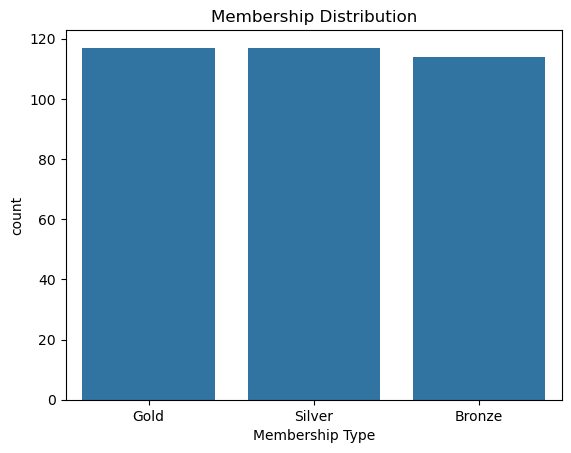

In [35]:
sns.countplot(x="Membership Type", data=df)
plt.title("Membership Distribution")
plt.show()

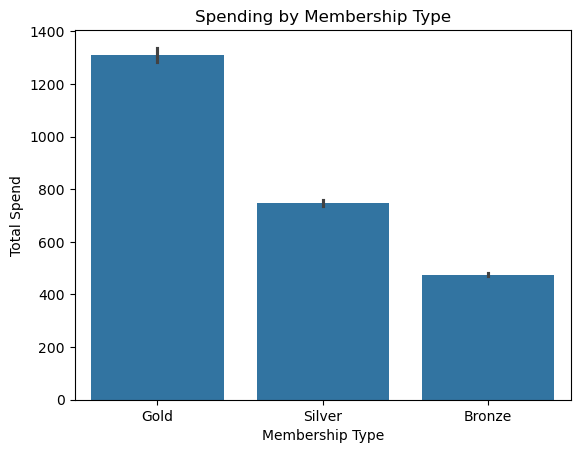

In [31]:
sns.barplot(x="Membership Type", y="Total Spend", data=df)
plt.title("Spending by Membership Type")
plt.show()

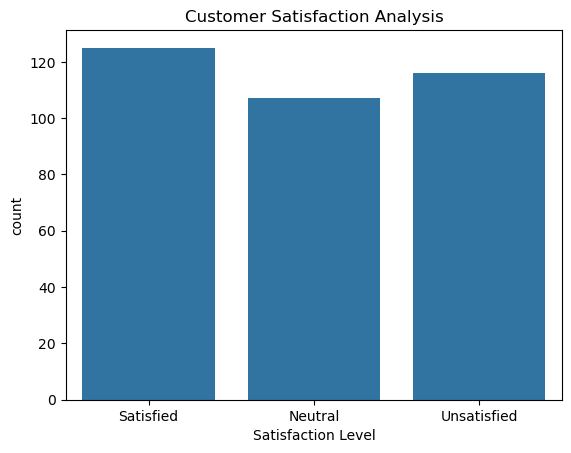

In [37]:
sns.countplot(x="Satisfaction Level", data=df)
plt.title("Customer Satisfaction Analysis")
plt.show()

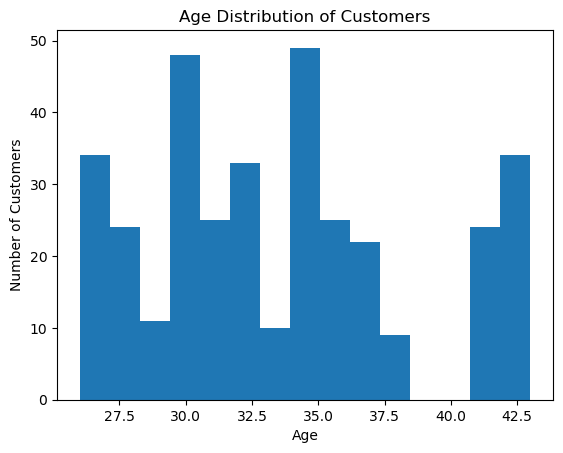

In [39]:
plt.hist(df["Age"], bins=15)
plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

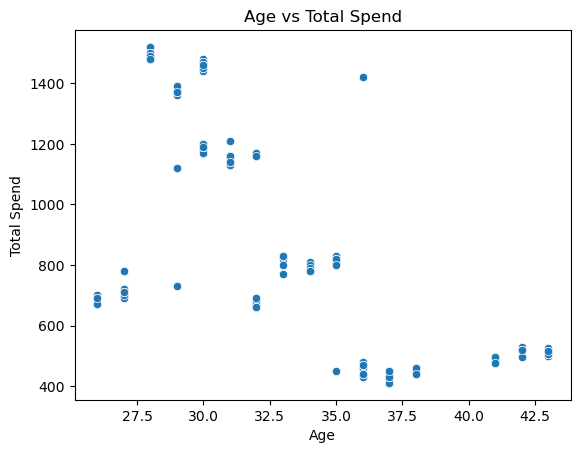

In [43]:
sns.scatterplot(x="Age", y="Total Spend", data=df)
plt.title("Age vs Total Spend")
plt.show()

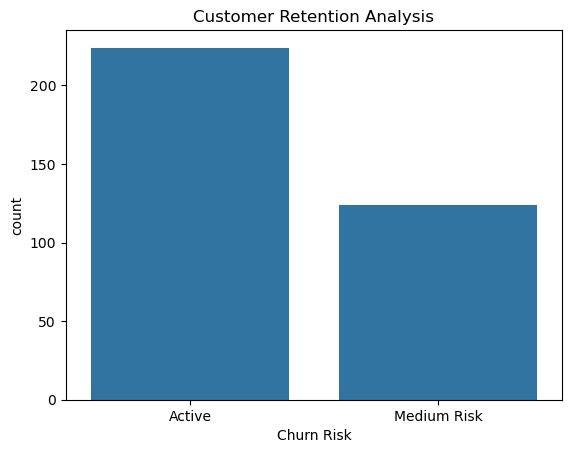

In [44]:
sns.countplot(x="Churn Risk", data=df)

plt.title("Customer Retention Analysis")

plt.show()

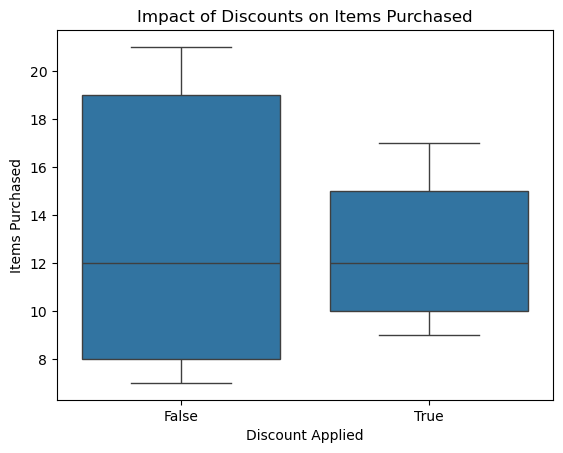

In [45]:
sns.boxplot(x="Discount Applied", y="Items Purchased", data=df)
plt.title("Impact of Discounts on Items Purchased")
plt.show()

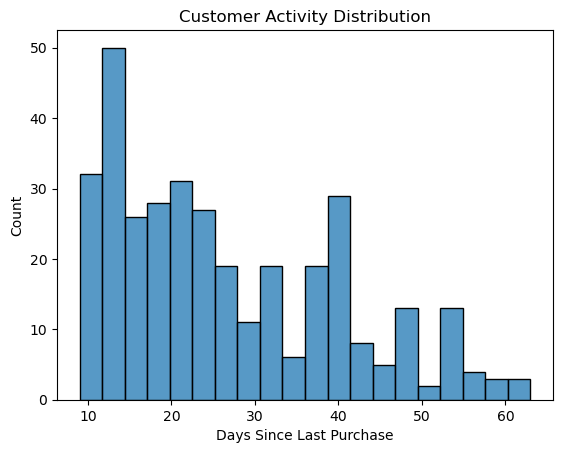

In [46]:
sns.histplot(df["Days Since Last Purchase"], bins=20)
plt.title("Customer Activity Distribution")
plt.xlabel("Days Since Last Purchase")
plt.show()

### Business Insights

- Gold membership customers show the highest spending behavior.
- Customers who receive discounts are more likely to spend more.
- Customers inactive for more than 60 days show potential churn risk.
- Customer satisfaction is strongly linked with higher spending.
- Certain age groups demonstrate higher purchasing power.

### Business Recommendations

1. Target high spenders with loyalty programs and provide discount incentives to low spenders.

2. Encourage Silver and Bronze customers to upgrade to Gold membership by providing exclusive offers.

3. Use targeted discounts for high-value customers to increase purchase frequency.

4. Customers who purchase a higher number of items can be rewarded with loyalty points or discount coupons. These rewards can be redeemed in future purchases to reduce the total order cost and encourage repeat buying.

https://github.com/Karunesh17/College-Assignment-Customer-behavior-analysis-project.git